In [ ]:
# ============================================
# CELL 1: IMPORTS 
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import warnings
import os
import json
import pickle

from scipy.signal import savgol_filter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Fix random seed
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print("Import successful!")
print(f"   sklearn version: OK")
print(f"   tensorflow version: {tf.__version__}")

Import successful!
   sklearn version: OK
   tensorflow version: 2.21.0


In [ ]:
# ============================================
# CELL 2: CONFIGURATION
# ============================================
RECORDS = ['100', '101', '103', '105', '109', '111', '112', '113', '115', '117']
WINDOW_SIZE = 5
TEST_SIZE = 0.3
VAL_SIZE = 0.15

# Hyperparameter grids 
RF_PARAMS = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

XGB_PARAMS = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Tạo folders
os.makedirs('results', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

print(f"Config loaded")
print(f"   Records: {len(RECORDS)}")
print(f"   Window size: {WINDOW_SIZE}")

Config loaded
   Records: 10
   Window size: 5


In [39]:
# ============================================
# CELL 3: LOAD AND PREPROCESS ECG
# ============================================
def load_ecg(record_id):
    """Load ECG record from MIT-BIH"""
    record = wfdb.rdrecord(record_id, pn_dir='mitdb')
    annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')
    return record, annotation

def get_heart_rate(annotation, fs=360):
    """Calculate heart rate from R-peaks"""
    r_peaks = annotation.sample
    rr_intervals = np.diff(r_peaks) / fs
    heart_rate = 60 / rr_intervals
    return heart_rate

def clean_hr(hr):
    """Clean heart rate signal"""
    # Remove outliers
    hr = hr[(hr > 30) & (hr < 220)]
    
    # Smoothing
    if len(hr) >= 5:
        try:
            hr = savgol_filter(hr, 5, 2)
        except:
            pass
    return hr

print("Loading ECG records...")
all_hr_series = []

for rec in RECORDS:
    print(f"  Processing {rec}...", end=" ")
    _, ann = load_ecg(rec)
    hr = get_heart_rate(ann)
    hr = clean_hr(hr)
    all_hr_series.append(hr)
    print(f"{len(hr)} samples")

print(f"\nLoaded {len(all_hr_series)} records")

Loading ECG records...
  Processing 100... 2272 samples
  Processing 101... 1868 samples
  Processing 103... 2088 samples
  Processing 105... 2616 samples
  Processing 109... 2533 samples
  Processing 111... 2131 samples
  Processing 112... 2540 samples
  Processing 113... 1795 samples
  Processing 115... 1956 samples
  Processing 117... 1538 samples

Loaded 10 records


In [40]:
# ============================================
# CELL 4: FEATURE ENGINEERING 
# ============================================
def create_features_full(hr_series, window=5):
    """
    Tạo features đầy đủ cho time series forecasting
    Bao gồm: lag features, statistics, trend, variability
    """
    X_list, y_list = [], []
    
    for hr in hr_series:
        X_rec, y_rec = [], []
        for i in range(window, len(hr)):
            past = hr[i-window:i]
            
            # 1. Lag features (5 features)
            lags = list(past)
            
            # 2. Statistical features (4 features)
            mean_past = np.mean(past)
            std_past = np.std(past)
            min_past = np.min(past)
            max_past = np.max(past)
            
            # 3. Trend feature (slope)
            slope = np.polyfit(range(window), past, 1)[0]
            
            # 4. Variability feature (RMSSD)
            diff = np.diff(past)
            rmssd = np.sqrt(np.mean(diff**2)) if len(diff) > 0 else 0
            
            # Combine all features: 5 + 4 + 1 + 1 = 11 features
            features = lags + [mean_past, std_past, min_past, max_past, slope, rmssd]
            
            X_rec.append(features)
            y_rec.append(hr[i])
        
        if len(X_rec) > 0:
            X_list.append(np.array(X_rec))
            y_list.append(np.array(y_rec))
    
    X_raw = np.concatenate(X_list)
    y_raw = np.concatenate(y_list)
    
    return X_raw, y_raw

FEATURE_NAMES = [
    'HR_t-5', 'HR_t-4', 'HR_t-3', 'HR_t-2', 'HR_t-1',
    'mean', 'std', 'min', 'max', 'slope', 'rmssd'
]

print("Creating features (11 features total)...")
print(f"   Features: {', '.join(FEATURE_NAMES)}")

X_raw, y_raw = create_features_full(all_hr_series, WINDOW_SIZE)

print(f"\nFeature matrix: {X_raw.shape}")
print(f"   Target vector: {y_raw.shape}")

Creating features (11 features total)...
   Features: HR_t-5, HR_t-4, HR_t-3, HR_t-2, HR_t-1, mean, std, min, max, slope, rmssd

Feature matrix: (21287, 11)
   Target vector: (21287,)


In [52]:
# ============================================
# CELL 5 ĐƠN GIẢN: STRATIFIED SPLIT
# ============================================
from sklearn.model_selection import train_test_split

# Tạo labels cho mỗi sample (record ID)
record_labels = []
for i, hr in enumerate(all_hr_series):
    record_labels.extend([i] * len(hr))

# Tạo features và targets từ tất cả records (giữ lại record labels)
X_raw_list, y_raw_list, record_labels_list = [], [], []

for i, hr in enumerate(all_hr_series):
    X, y = create_features_full([hr], WINDOW_SIZE)
    X_raw_list.append(X)
    y_raw_list.append(y)
    record_labels_list.append([i] * len(X))

X_raw = np.concatenate(X_raw_list)
y_raw = np.concatenate(y_raw_list)
record_labels = np.concatenate(record_labels_list)

# Split theo record labels (stratified)
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
train_idx, test_idx = next(sss.split(X_raw, record_labels))

X_train_raw = X_raw[train_idx]
X_test_raw = X_raw[test_idx]
y_train_raw = y_raw[train_idx]
y_test_raw = y_raw[test_idx]

# Tách validation từ train
from sklearn.model_selection import train_test_split
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=42
)

print(f"Stratified split complete")
print(f"   Train mean HR: {np.mean(y_train_raw):.2f}")
print(f"   Val mean HR:   {np.mean(y_val_raw):.2f}")
print(f"   Test mean HR:  {np.mean(y_test_raw):.2f}")

Stratified split complete
   Train mean HR: 73.43
   Val mean HR:   73.75
   Test mean HR:  73.43


In [53]:
# ============================================
# CELL 6: SCALING
# ============================================
# Feature scaler - fit only on train
feature_scaler = StandardScaler()
X_train = feature_scaler.fit_transform(X_train_raw)
X_val = feature_scaler.transform(X_val_raw)
X_test = feature_scaler.transform(X_test_raw)

# Target scaler (for LSTM)
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val_raw.reshape(-1, 1)).flatten()

print(f"Scaling complete")
print(f"   Train mean: {X_train[:,0].mean():.6f}, std: {X_train[:,0].std():.6f}")

# Save scalers
with open('results/models/feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
with open('results/models/target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

Scaling complete
   Train mean: -0.000000, std: 1.000000


In [ ]:
# ============================================
# CELL 7: RANDOM FOREST (Dùng GridSearchCV)
# ============================================
print("\nTraining Random Forest...")
print("="*50)

# Tham số đơn giản để nhanh chóng kiểm tra chất lượng RF 
RF_PARAMS_SIMPLE = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf, RF_PARAMS_SIMPLE, cv=3,
    scoring='neg_mean_squared_error', n_jobs=-1
)
rf_grid.fit(X_train, y_train_raw)

best_rf = rf_grid.best_estimator_
print(f"   Best params: {rf_grid.best_params_}")
print(f"   Best CV RMSE: {np.sqrt(-rf_grid.best_score_):.4f} BPM")

# Predict
rf_pred = best_rf.predict(X_test)

# Save model
with open('results/models/rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print(f"Random Forest done")


Training Random Forest...
   Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV RMSE: 4.0532 BPM
Random Forest done


In [ ]:
# ============================================
# CELL 8: XGBOOST 
# ============================================
print("\nTraining XGBoost...")
print("="*50)

# Clear previous predictions 
if 'xgb_pred' in globals():
    del xgb_pred

XGB_PARAMS_SIMPLE = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1]
}

xgb = XGBRegressor(random_state=42, verbosity=0)

xgb_grid = GridSearchCV(
    xgb, XGB_PARAMS_SIMPLE, cv=3,
    scoring='neg_mean_squared_error', n_jobs=-1
)
xgb_grid.fit(X_train, y_train_raw)

best_xgb = xgb_grid.best_estimator_
print(f"   Best params: {xgb_grid.best_params_}")
print(f"   Best CV RMSE: {np.sqrt(-xgb_grid.best_score_):.4f} BPM")

# Predict 
xgb_pred = best_xgb.predict(X_test)
print(f"   xgb_pred shape: {xgb_pred.shape}")

# Save model
with open('results/models/xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print(f"XGBoost done")


Training XGBoost...
   Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
   Best CV RMSE: 4.1704 BPM
   xgb_pred shape: (6387,)
XGBoost done



Training LSTM...


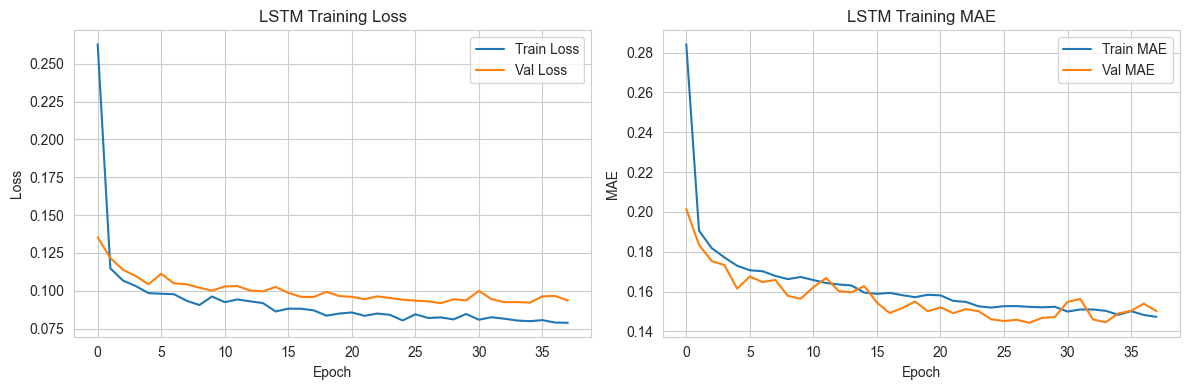

LSTM done


In [56]:
# ============================================
# CELL 9: LSTM
# ============================================
print("\nTraining LSTM...")
print("="*50)

# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_lstm = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build model
model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = model.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=50, batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

# Predict and inverse transform
lstm_pred_scaled = model.predict(X_test_lstm, verbose=0).flatten()
lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

# Save model
model.save('results/models/lstm_model.h5')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Training Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('LSTM Training MAE')
plt.tight_layout()
plt.savefig('results/figures/lstm_history.png', dpi=150)
plt.show()

print(f"LSTM done")

In [62]:
# ============================================
# CELL 10: EVALUATION
# ============================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def evaluate(y_true, y_pred, name):
    """Calculate and print metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse:.4f} BPM")
    print(f"   MAE:  {mae:.4f} BPM")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   R²:   {r2:.4f}")
    
    return {'model': name, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)

results = []
results.append(evaluate(y_test_raw, rf_pred, "Random Forest"))
results.append(evaluate(y_test_raw, xgb_pred, "XGBoost"))

# Lưu ý: LSTM có thể có số samples khác
min_len = min(len(y_test_raw), len(lstm_pred))
results.append(evaluate(y_test_raw[:min_len], lstm_pred[:min_len], "LSTM"))

results_df = pd.DataFrame(results).sort_values('rmse')

print(f"\n{'='*50}")
print("BEST MODEL:", results_df.iloc[0]['model'])
print(f"RMSE: {results_df.iloc[0]['rmse']:.4f} BPM")
print(f"R²:   {results_df.iloc[0]['r2']:.4f}")

# Save results
results_df.to_csv('results/model_results.csv', index=False)
print(f"\nResults saved to results/model_results.csv")


EVALUATION RESULTS

Random Forest:
   RMSE: 4.0117 BPM
   MAE:  1.8166 BPM
   MAPE: 2.36%
   R²:   0.9127

XGBoost:
   RMSE: 4.0358 BPM
   MAE:  1.9081 BPM
   MAPE: 2.48%
   R²:   0.9116

LSTM:
   RMSE: 3.8444 BPM
   MAE:  1.9289 BPM
   MAPE: 2.56%
   R²:   0.9198

BEST MODEL: LSTM
RMSE: 3.8444 BPM
R²:   0.9198

Results saved to results/model_results.csv


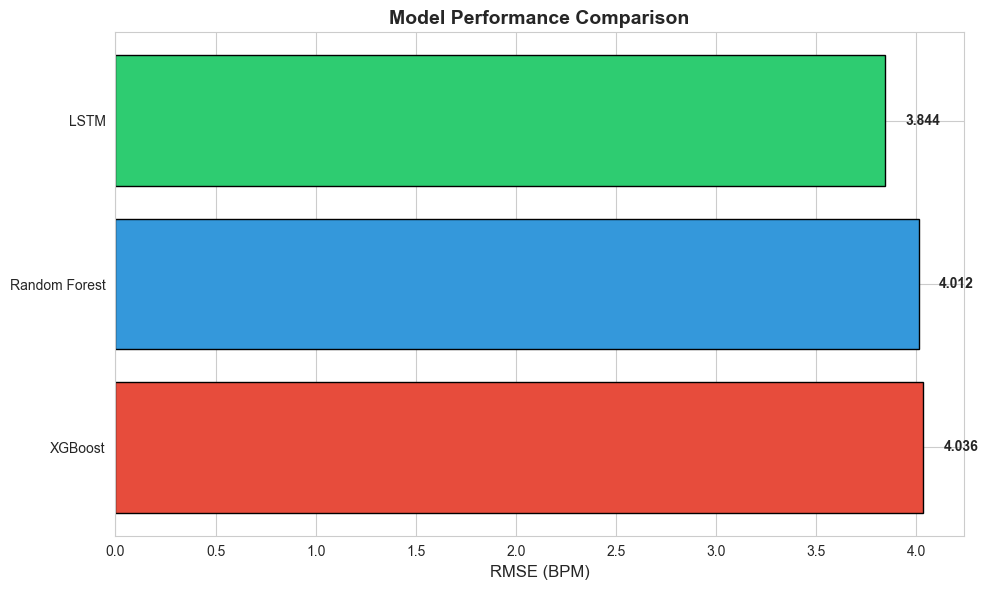

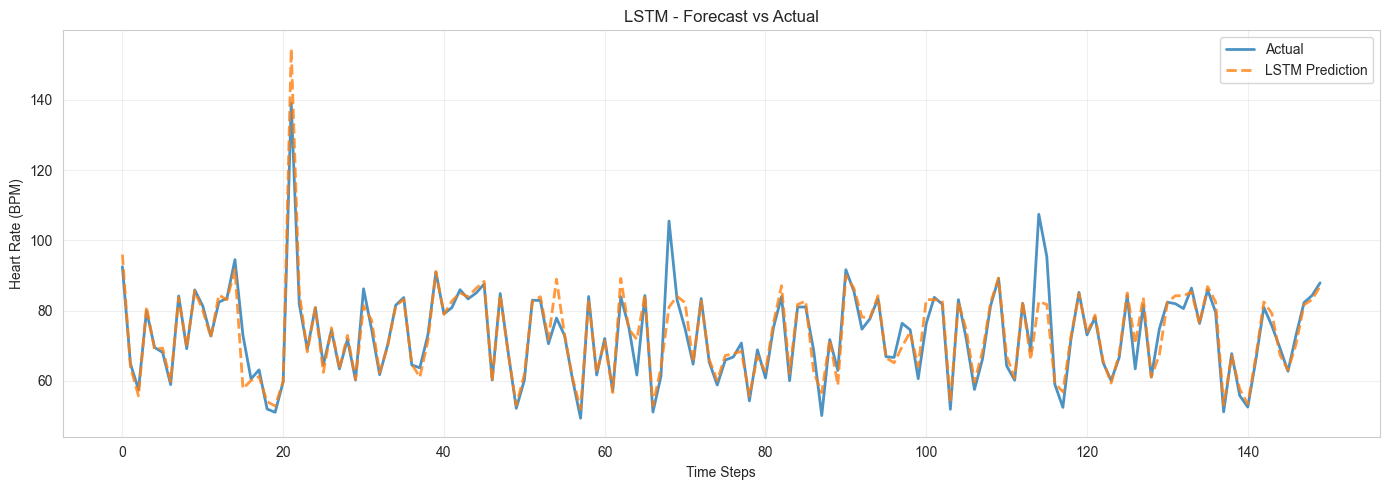

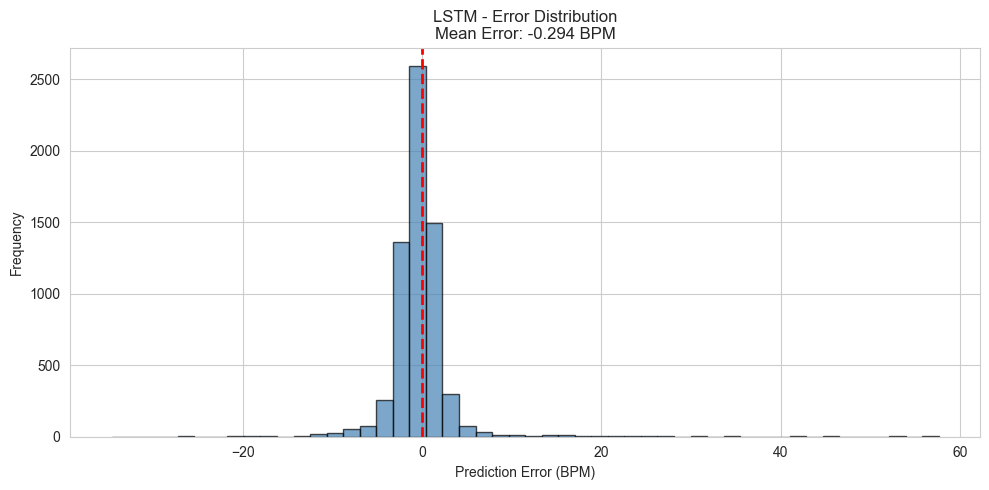

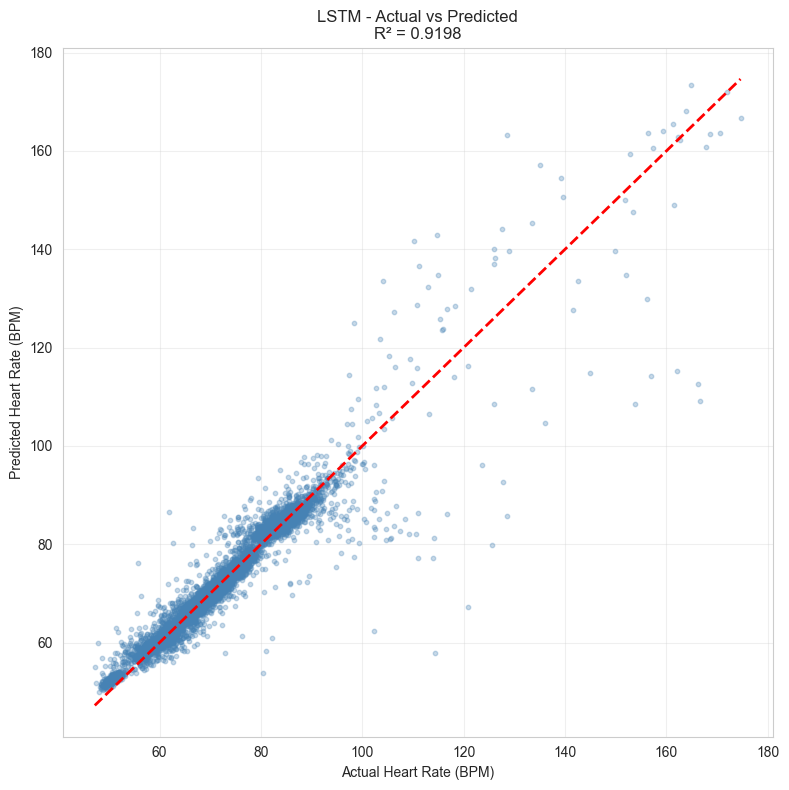

All figures saved to results/figures/


In [63]:
# ============================================
# CELL 11: VISUALIZATIONS
# ============================================
# Figure 1: RMSE Comparison
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.barh(results_df['model'], results_df['rmse'], color=colors, edgecolor='black')
ax.set_xlabel('RMSE (BPM)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, results_df['rmse']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/figures/rmse_comparison.png', dpi=150)
plt.show()

# Figure 2: Forecast vs Actual (Best model)
best_model = results_df.iloc[0]['model']
best_pred_map = {'Random Forest': rf_pred, 'XGBoost': xgb_pred, 'LSTM': lstm_pred}
best_pred = best_pred_map[best_model]

plt.figure(figsize=(14, 5))
plt.plot(y_test_raw[:150], label='Actual', linewidth=2, alpha=0.8)
plt.plot(best_pred[:150], label=f'{best_model} Prediction', linewidth=2, alpha=0.8, linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Heart Rate (BPM)')
plt.title(f'{best_model} - Forecast vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/forecast_vs_actual.png', dpi=150)
plt.show()

# Figure 3: Error Distribution
best_error = y_test_raw - best_pred
plt.figure(figsize=(10, 5))
plt.hist(best_error, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (BPM)')
plt.ylabel('Frequency')
plt.title(f'{best_model} - Error Distribution\nMean Error: {np.mean(best_error):.3f} BPM')
plt.tight_layout()
plt.savefig('results/figures/error_distribution.png', dpi=150)
plt.show()

# Figure 4: Actual vs Predicted Scatter
plt.figure(figsize=(8, 8))
plt.scatter(y_test_raw, best_pred, alpha=0.3, s=10, c='steelblue')
min_val = min(y_test_raw.min(), best_pred.min())
max_val = max(y_test_raw.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Actual Heart Rate (BPM)')
plt.ylabel('Predicted Heart Rate (BPM)')
plt.title(f'{best_model} - Actual vs Predicted\nR² = {results_df.iloc[0]["r2"]:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/actual_vs_predicted.png', dpi=150)
plt.show()

print("All figures saved to results/figures/")


SHAP Analysis...


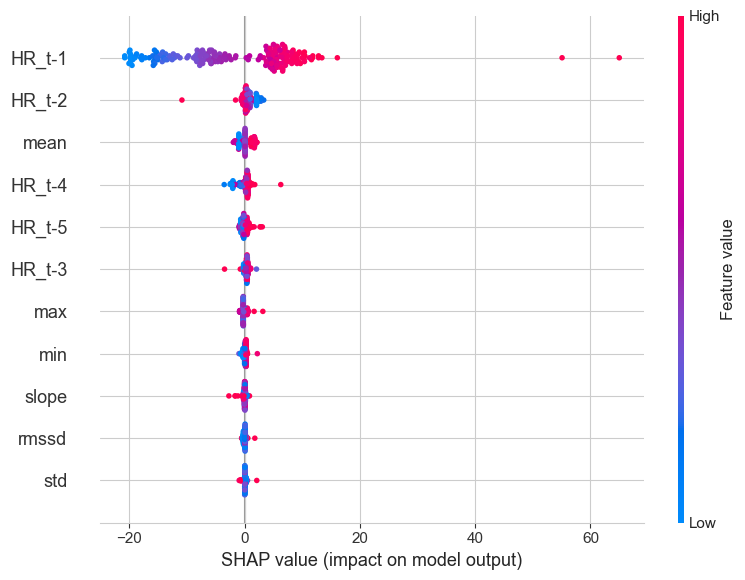


Feature Importance (by mean |SHAP|):
---------------------------------------------
   1. HR_t-1      : 9.356075 ████████████████████████████████████████
   2. HR_t-2      : 0.864605 ███
   3. mean        : 0.782731 ███
   4. HR_t-4      : 0.666509 ██
   5. HR_t-5      : 0.414559 █
   6. HR_t-3      : 0.368157 █
   7. max         : 0.316161 █
   8. min         : 0.195221 
   9. slope       : 0.131499 
   10. rmssd       : 0.119999 
   11. std         : 0.118908 

SHAP analysis complete


In [64]:
# ============================================
# CELL 12: SHAP ANALYSIS
# ============================================
print("\nSHAP Analysis...")

# Use best tree-based model
best_tree = best_rf if best_model == 'Random Forest' else best_xgb

# Create explainer
explainer = shap.TreeExplainer(best_tree)

# Get SHAP values (subset for speed)
X_sample = X_test[:200]
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance ranking
mean_shap = np.abs(shap_values).mean(axis=0)
ranking = sorted(zip(FEATURE_NAMES, mean_shap), key=lambda x: x[1], reverse=True)

print("\nFeature Importance (by mean |SHAP|):")
print("-" * 45)
for i, (f, imp) in enumerate(ranking, 1):
    bar = '█' * int(imp * 40 / max(mean_shap))
    print(f"   {i}. {f:12s}: {imp:.6f} {bar}")

# Save SHAP values
np.save('results/shap_values.npy', shap_values)

print("\nSHAP analysis complete")

In [65]:
# ============================================
# CELL 13: SAVE ALL RESULTS
# ============================================
# Save predictions
pred_df = pd.DataFrame({
    'actual': y_test_raw,
    'rf_pred': rf_pred,
    'xgb_pred': xgb_pred,
    'lstm_pred': lstm_pred
})
pred_df.to_csv('results/predictions.csv', index=False)

# Save summary (convert numpy types to Python types)
summary = {
    'best_model': str(best_model),
    'best_rmse': float(results_df.iloc[0]['rmse']),
    'best_r2': float(results_df.iloc[0]['r2']),
    'feature_importance': [(f, float(imp)) for f, imp in ranking[:5]]
}

with open('results/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print final summary
print("\n" + "="*60)
print("PROJECT COMPLETE!")
print("="*60)
print(f"\nBEST MODEL: {best_model}")
print(f"   RMSE: {results_df.iloc[0]['rmse']:.4f} BPM")
print(f"   R²:   {results_df.iloc[0]['r2']:.4f}")

print(f"\nResults saved to 'results/' folder:")
print(f"   - model_results.csv  (performance comparison)")
print(f"   - predictions.csv    (all predictions)")
print(f"   - summary.json       (summary for report)")
print(f"   - figures/*.png      (visualizations)")
print(f"   - models/*.pkl, *.h5 (trained models)")

print("\n" + "="*60)


PROJECT COMPLETE!

BEST MODEL: LSTM
   RMSE: 3.8444 BPM
   R²:   0.9198

Results saved to 'results/' folder:
   - model_results.csv  (performance comparison)
   - predictions.csv    (all predictions)
   - summary.json       (summary for report)
   - figures/*.png      (visualizations)
   - models/*.pkl, *.h5 (trained models)



In [69]:
# ============================================
# DEBUG: Kiểm tra chất lượng RF và XGBoost
# ============================================
print("DIAGNOSIS")
print("="*50)

# 1. Kiểm tra baseline (dự đoán bằng giá trị trung bình)
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train_raw)
dummy_pred = dummy.predict(X_test)
dummy_rmse = np.sqrt(mean_squared_error(y_test_raw, dummy_pred))

print(f"\n1. Baseline (predict mean):")
print(f"   RMSE: {dummy_rmse:.4f} BPM")
print(f"   Nếu RF/XGBoost có RMSE > baseline → model không học được gì")

# 2. Kiểm tra bias (xu hướng sai lệch)
print(f"\n2. Model Bias (Mean Error):")
print(f"   Random Forest: {np.mean(y_test_raw - rf_pred):.4f} BPM")
print(f"   XGBoost:       {np.mean(y_test_raw - xgb_pred):.4f} BPM")
print(f"   LSTM:          {np.mean(y_test_raw[:len(lstm_pred)] - lstm_pred):.4f} BPM")
print(f"   (Bias gần 0 là tốt)")

# 3. Kiểm tra phân phối dữ liệu
print(f"\n3. Data Distribution:")
print(f"   y_train mean: {np.mean(y_train_raw):.2f}, std: {np.std(y_train_raw):.2f}")
print(f"   y_test mean:  {np.mean(y_test_raw):.2f}, std: {np.std(y_test_raw):.2f}")
print(f"   Nếu train/test distribution khác nhau nhiều → generalization kém")

# 4. Kiểm tra feature ranges
print(f"\n4. Feature ranges (X_train):")
for i, name in enumerate(FEATURE_NAMES[:5]):  # Chỉ 5 feature đầu
    print(f"   {name}: [{X_train[:,i].min():.2f}, {X_train[:,i].max():.2f}]")

DIAGNOSIS

1. Baseline (predict mean):
   RMSE: 13.5748 BPM
   Nếu RF/XGBoost có RMSE > baseline → model không học được gì

2. Model Bias (Mean Error):
   Random Forest: -0.1361 BPM
   XGBoost:       -0.1022 BPM
   LSTM:          -0.2943 BPM
   (Bias gần 0 là tốt)

3. Data Distribution:
   y_train mean: 73.43, std: 13.67
   y_test mean:  73.43, std: 13.57
   Nếu train/test distribution khác nhau nhiều → generalization kém

4. Feature ranges (X_train):
   HR_t-5: [-2.00, 7.79]
   HR_t-4: [-2.00, 7.83]
   HR_t-3: [-2.01, 7.93]
   HR_t-2: [-2.01, 7.91]
   HR_t-1: [-1.90, 7.95]


In [70]:
# ============================================
# SO SÁNH CHI TIẾT
# ============================================
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

# Lấy metrics từ evaluation
for _, row in results_df.iterrows():
    print(f"\n{row['model']}:")
    print(f"   RMSE: {row['rmse']:.4f} BPM")
    print(f"   R²:   {row['r2']:.4f}")
    print(f"   Improvement over baseline: {(1 - row['rmse']/13.57)*100:.1f}%")

# Kết luận
best = results_df.iloc[0]
print(f"\n{'='*60}")
print(f"BEST MODEL: {best['model']}")
print(f"   RMSE: {best['rmse']:.4f} BPM")
print(f"   R²:   {best['r2']:.4f}")
print(f"   {'='*40}")


FINAL RESULTS

LSTM:
   RMSE: 3.8444 BPM
   R²:   0.9198
   Improvement over baseline: 71.7%

Random Forest:
   RMSE: 4.0117 BPM
   R²:   0.9127
   Improvement over baseline: 70.4%

XGBoost:
   RMSE: 4.0358 BPM
   R²:   0.9116
   Improvement over baseline: 70.3%

BEST MODEL: LSTM
   RMSE: 3.8444 BPM
   R²:   0.9198
